# Качество воды в местах для купания — EDA

**Домен:** Supluskohad (supluskohad_uuringud)  
**Источник:** Terviseamet — vtiav.sm.ee  
**Цель:** Первичное знакомство с данными: структура, распределение, аномалии.

**Google Colab:** сначала [colab_quickstart.ipynb](colab_quickstart.ipynb); если импорты не находят проект, в начале первой кодовой ячейки выполните `%cd /content/water-quality-ee` (или путь к клону на Drive).

---
## Вопросы, которые хотим ответить:
1. Сколько проб, за какой период?
2. Какой % нарушений?
3. Какие параметры чаще всего нарушаются?
4. Есть ли сезонность? Географические различия?
5. Какие признаки могут быть полезны для модели?

In [2]:
# Надёжно: один раз в терминале из корня репозитория (тот же Python, что и у этого kernel):
#   pip install -e .
import importlib.util
import os
import subprocess
import sys
from pathlib import Path


def _project_root() -> Path:
    """Корень репозитория (где лежат src/ и data/)."""
    spec = importlib.util.find_spec('data_loader')
    if spec is not None and getattr(spec, 'origin', None):
        cand = Path(spec.origin).resolve().parent.parent
        if (cand / 'data' / 'raw').is_dir() or (cand / 'src' / 'data_loader.py').is_file():
            return cand
    env = os.environ.get('WATER_QUALITY_EE_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'src' / 'data_loader.py').is_file():
            return p
    cwd = Path.cwd().resolve()
    try:
        r = subprocess.run(
            ['git', 'rev-parse', '--show-toplevel'],
            cwd=cwd,
            capture_output=True,
            text=True,
            timeout=15,
        )
        if r.returncode == 0 and r.stdout.strip():
            p = Path(r.stdout.strip()).resolve()
            if (p / 'src' / 'data_loader.py').is_file():
                return p
    except (FileNotFoundError, OSError, subprocess.TimeoutExpired):
        pass
    for root in [cwd, *list(cwd.parents)[:28]]:
        if (root / 'src' / 'data_loader.py').is_file():
            return root
    raise RuntimeError(
        'Не найден проект. Выберите интерпретатор из .venv этого репозитория и выполните в терминале:\n'
        '  cd <корень water-quality-ee> && pip install -e .\n'
        'WATER_QUALITY_EE_ROOT должен указывать на путь, видимый машине, где крутится Jupyter (не чужой WSL-путь).'
    )


if importlib.util.find_spec('data_loader') is None:
    _src = str(_project_root() / 'src')
    if _src not in sys.path:
        sys.path.insert(0, _src)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_domain
from features import add_time_features

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Библиотеки загружены ✓')

Библиотеки загружены ✓


## 1. Загрузка данных

In [3]:
df = load_domain('supluskoha')
print(f'Загружено проб: {len(df)}')
print(f'Колонки: {df.columns.tolist()}')

[data_loader] Скачиваю supluskoha за 2026…
[data_loader] Год 2026 недоступен: 404 Client Error: Not Found for url: https://vtiav.sm.ee/index.php/opendata/supluskoha_veeproovid_2026.xml
[data_loader] Кэш: supluskoha_2025.xml
[data_loader] Кэш: supluskoha_2024.xml
[data_loader] Кэш: supluskoha_2023.xml
[data_loader] Кэш: supluskoha_2022.xml
[data_loader] Кэш: supluskoha_2021.xml
[data_loader] supluskoha: 4031 проб, 4031 с известным статусом
Загружено проб: 4031
Колонки: ['domain', 'sample_id', 'location', 'county', 'sample_date', 'e_coli', 'enterococci', 'ph', 'transparency', 'compliant']


In [4]:
df.head(10)

,domain,sample_id,location,county,sample_date,e_coli,enterococci,ph,transparency,compliant
0,supluskoha,370465,Pirita rand,None,2025-10-02,30.0,None,None,None,1
1,supluskoha,369939,Pirita rand,None,2025-09-25,30.0,None,None,None,1
2,supluskoha,369365,Pirita rand,None,2025-09-22,820.0,None,None,None,0
3,supluskoha,368215,Pirita rand,None,2025-09-08,30.0,None,None,None,1
4,supluskoha,367055,Kuressaare supelrand,None,2025-08-28,NaN,None,None,None,1
5,supluskoha,367046,Pärnu Keskrand,None,2025-08-27,NaN,None,None,None,1
6,supluskoha,367047,Raeküla rand,None,2025-08-27,NaN,None,None,None,1
7,supluskoha,366874,Kabli rand,None,2025-08-26,NaN,None,None,None,1
8,supluskoha,366813,Kakumäe rand,None,2025-08-26,NaN,None,None,None,1
9,supluskoha,366835,Pirita rand,None,2025-08-26,NaN,None,None,None,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   domain        4031 non-null   str           
 1   sample_id     4031 non-null   str           
 2   location      4031 non-null   str           
 3   county        0 non-null      object        
 4   sample_date   4031 non-null   datetime64[us]
 5   e_coli        3669 non-null   float64       
 6   enterococci   0 non-null      object        
 7   ph            0 non-null      object        
 8   transparency  0 non-null      object        
 9   compliant     4031 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), object(4), str(3)
memory usage: 315.1+ KB


In [6]:
df.describe()

,sample_date,e_coli,compliant
count,4031,3669.000000,4031.000000
mean,2023-06-30 01:58:40.605309,149.636686,0.926569
min,2021-05-12 00:00:00,0.000000,0.000000
25%,2022-06-10 00:00:00,10.000000,1.000000
50%,2023-07-06 09:30:00,30.000000,1.000000
75%,2024-07-31 12:00:00,60.000000,1.000000
max,2025-10-02 00:00:00,100000.000000,1.000000
std,NaN,2365.964493,0.260875


## 2. Пропущенные значения

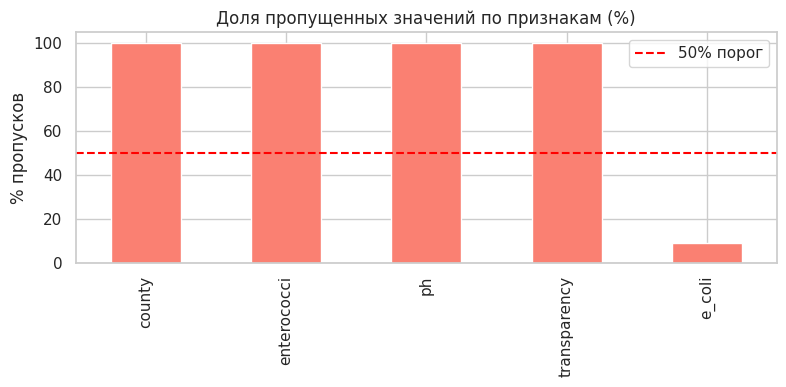

county          100.000000
enterococci     100.000000
ph              100.000000
transparency    100.000000
e_coli            8.980402
dtype: float64


In [7]:
missing = df.isnull().sum() / len(df) * 100
missing_df = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
missing_df.plot(kind='bar', ax=ax, color='salmon')
ax.set_title('Доля пропущенных значений по признакам (%)')
ax.set_ylabel('% пропусков')
ax.axhline(y=50, color='red', linestyle='--', label='50% порог')
ax.legend()
plt.tight_layout()
plt.show()

print(missing_df)

## 3. Целевая переменная: баланс классов

Проб с известным статусом: 4031 из 4031

Распределение:
compliant
1    3735
0     296
Name: count, dtype: int64

% нарушений: 7.3%


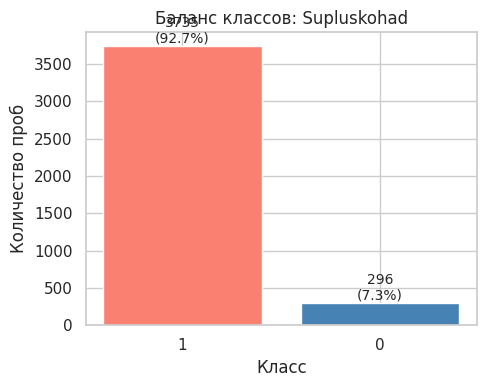

In [8]:
from evaluate import plot_class_distribution

df_labeled = df.dropna(subset=['compliant'])
print(f'Проб с известным статусом: {len(df_labeled)} из {len(df)}')
print(f'\nРаспределение:')
print(df_labeled['compliant'].value_counts())
print(f'\n% нарушений: {(df_labeled["compliant"] == 0).mean() * 100:.1f}%')

plot_class_distribution(df_labeled['compliant'], title='Баланс классов: Supluskohad')

## 4. Временная динамика

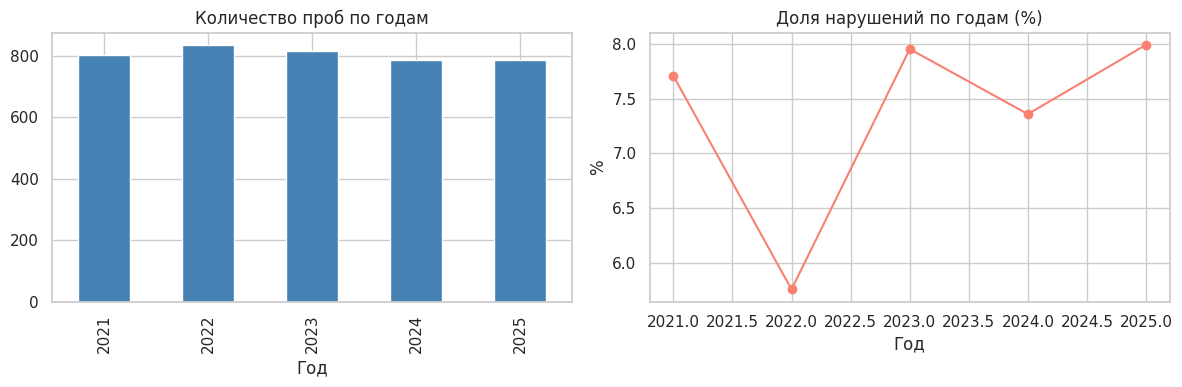

In [9]:
df_time = add_time_features(df_labeled)

# Нарушения по годам
yearly = df_time.groupby('year')['compliant'].agg(
    total='count',
    violations=lambda x: (x == 0).sum()
)
yearly['violation_rate'] = yearly['violations'] / yearly['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

yearly['total'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Количество проб по годам')
axes[0].set_xlabel('Год')

yearly['violation_rate'].plot(kind='line', marker='o', ax=axes[1], color='salmon')
axes[1].set_title('Доля нарушений по годам (%)')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

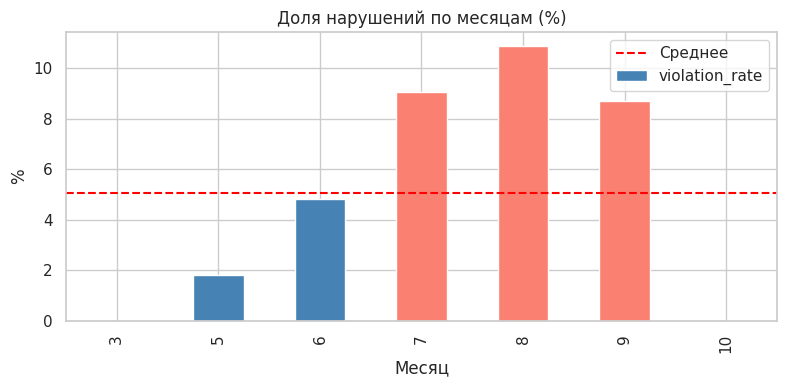

In [10]:
# Сезонность (купальный сезон = лето)
monthly = df_time.groupby('month')['compliant'].agg(
    total='count',
    violations=lambda x: (x == 0).sum()
)
monthly['violation_rate'] = monthly['violations'] / monthly['total'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
monthly['violation_rate'].plot(kind='bar', ax=ax, color=['salmon' if v > monthly['violation_rate'].mean() else 'steelblue' 
                                                           for v in monthly['violation_rate']])
ax.set_title('Доля нарушений по месяцам (%)')
ax.set_xlabel('Месяц')
ax.set_ylabel('%')
ax.axhline(y=monthly['violation_rate'].mean(), color='red', linestyle='--', label='Среднее')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Географический анализ

Поле county пустое — типично для текущего формата opendata. Ниже: топ мест купания (location).


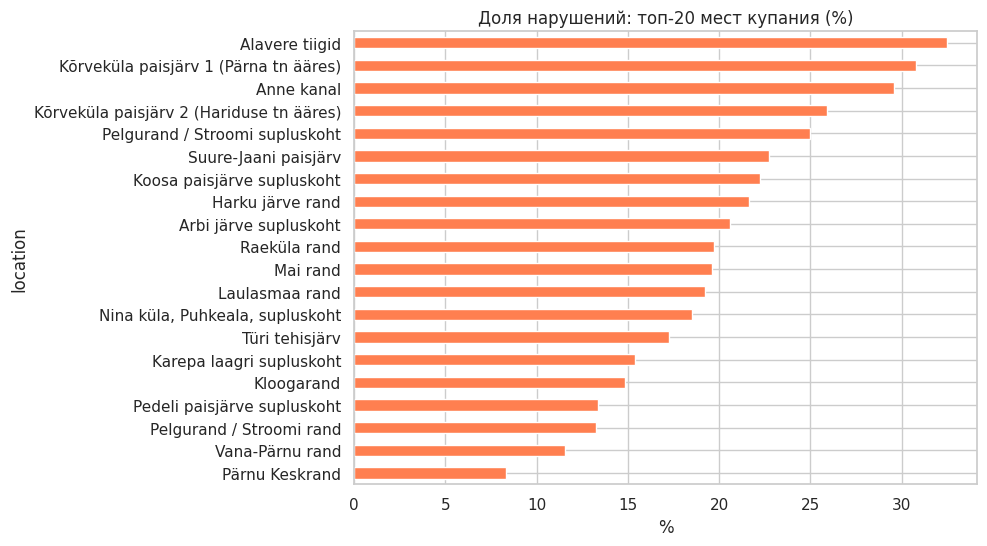

Топ-5 мест по числу нарушений:
                          total  violations  violation_rate
location                                                   
Anne kanal                  142          42       29.577465
Raeküla rand                 76          15       19.736842
Alavere tiigid               40          13       32.500000
Pelgurand / Stroomi rand     83          11       13.253012
Türi tehisjärv               58          10       17.241379


In [11]:
# Нарушения по уездам (в opendata XML поле county часто пустое)
df_co = df_labeled.dropna(subset=['county'])
df_co = df_co[df_co['county'].astype(str).str.strip().ne('')]
if len(df_co) > 0:
    county_stats = df_co.groupby('county')['compliant'].agg(
        total='count',
        violations=lambda x: (x == 0).sum()
    ).sort_values('violations', ascending=False)
    county_stats['violation_rate'] = county_stats['violations'] / county_stats['total'] * 100
    fig, ax = plt.subplots(figsize=(10, 5))
    county_stats['violation_rate'].sort_values().plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Доля нарушений по уездам (%)')
    ax.set_xlabel('%')
    ax.axvline(x=county_stats['violation_rate'].mean(), color='red', linestyle='--', label='Среднее')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('Топ-5 уездов по количеству нарушений:')
    print(county_stats.head())
else:
    print('Поле county пустое — типично для текущего формата opendata. Ниже: топ мест купания (location).')

# Топ мест по нарушениям (всегда есть в opendata)
df_loc = df_labeled.dropna(subset=['location'])
df_loc = df_loc[df_loc['location'].astype(str).str.strip().ne('')]
loc_stats = df_loc.groupby('location')['compliant'].agg(
    total='count',
    violations=lambda x: (x == 0).sum()
).sort_values('violations', ascending=False)
loc_stats['violation_rate'] = loc_stats['violations'] / loc_stats['total'] * 100
top_n = min(20, len(loc_stats))
if top_n > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.28)))
    loc_stats.head(top_n)['violation_rate'].sort_values().plot(kind='barh', ax=ax, color='coral')
    ax.set_title(f'Доля нарушений: топ-{top_n} мест купания (%)')
    ax.set_xlabel('%')
    plt.tight_layout()
    plt.show()
print('Топ-5 мест по числу нарушений:')
print(loc_stats.head())

## 6. Распределение числовых параметров

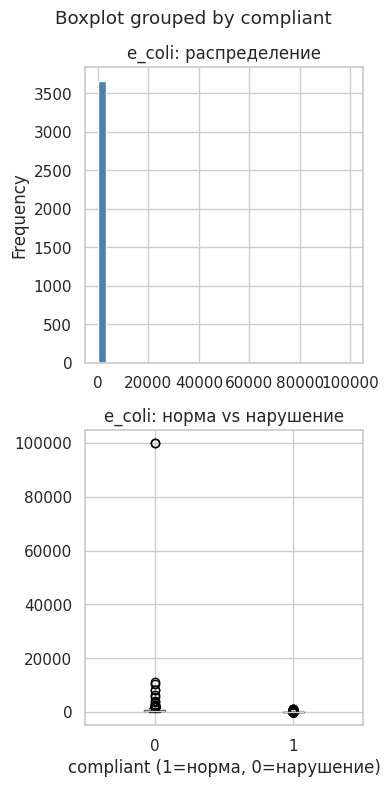

In [12]:
# Числовые параметры для supluskohad
numeric_cols = ['e_coli', 'enterococci', 'ph', 'transparency']
available_cols = []
for c in numeric_cols:
    if c not in df_labeled.columns:
        continue
    s = pd.to_numeric(df_labeled[c], errors='coerce')
    if s.notna().sum() == 0:
        continue
    available_cols.append(c)
    df_labeled[c] = s

if not available_cols:
    print('Нет числовых колонок с данными для гистограмм (все NaN или отсутствуют).')
else:
    n = len(available_cols)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    for i, col in enumerate(available_cols):
        df_labeled[col].dropna().plot(kind='hist', bins=30, ax=axes[0, i], color='steelblue', edgecolor='white')
        axes[0, i].set_title(f'{col}: распределение')
        df_labeled.boxplot(column=col, by='compliant', ax=axes[1, i])
        axes[1, i].set_title(f'{col}: норма vs нарушение')
        axes[1, i].set_xlabel('compliant (1=норма, 0=нарушение)')
    plt.tight_layout()
    plt.show()

## 7. Корреляционная матрица

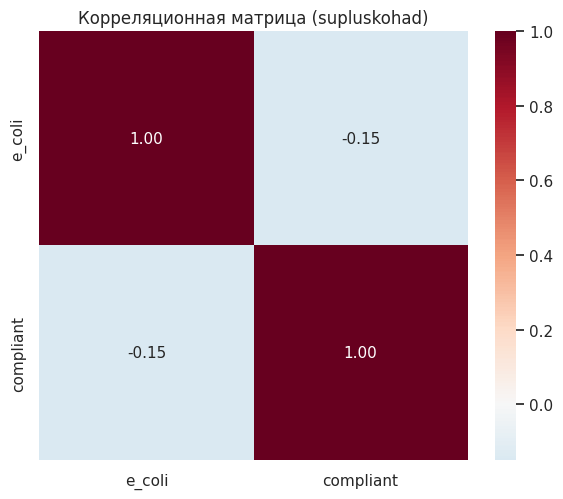

In [13]:
cols_for_corr = [c for c in available_cols if c in df_labeled.columns] + ['compliant']
if len(cols_for_corr) < 2:
    print('Недостаточно числовых колонок для корреляций.')
else:
    corr = df_labeled[cols_for_corr].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, ax=ax)
    ax.set_title('Корреляционная матрица (supluskohad)')
    plt.tight_layout()
    plt.show()

## 8. Итог EDA: ключевые инсайты

1. **Объём данных:** 4 031 проба воды из купальных мест (supluskoha), 2021–2025. Все пробы содержат метку качества.
2. **Баланс классов:** несбалансированный — **7.3% нарушений** (296 проб) vs 92.7% нормы. Необходим `class_weight='balanced'`.
3. **Главные нарушители:** E. coli и кишечные энтерококки нарушают нормы одинаково часто (по 133 случая из ~3 670 измерений, ~3.6%). Максимальный E. coli: 100 000 КОЕ/100 мл при норме 500.
4. **Сезонность:** летом (июнь–август) нарушений значительно больше, чем весной — 8.5% vs 1.8%. Купальная нагрузка увеличивает микробное загрязнение.
5. **Проблемные локации:** Anne kanal (Тарту) — 42 нарушения из 142 проб (29.6%). Alavere tiigid — 32.5% нарушений.
6. **Пропуски:** pH и прозрачность (transparency) отсутствуют во всём датасете opendata (100% пропусков) — поля недоступны в текущем формате XML. E. coli и enterococci измеряются в 91% проб.
7. **Для модели:** основные признаки — `e_coli`, `enterococci`, `e_coli_ratio`, `enterococci_ratio`, `is_summer`, `month`. Индикаторы пропуска (`enterococci_missing`) несут дополнительную информацию о типе пробы.